In [ ]:
#perform Data preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
df = pd.read_csv('employee_data.csv')
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Education'] = le.fit_transform(df['Education'])
df['Department'] = le.fit_transform(df['Department'])
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category'], axis=1)
y_reg = df['Salary']
y_clf = le.fit_transform(df['Salary_Category'])
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_scaled)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_scaled)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf = rf_reg.predict(X_test)

In [ ]:
#Linear Regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv('employee_data.csv')
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Education'] = le.fit_transform(df['Education'])
df['Department'] = le.fit_transform(df['Department'])
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category'], axis=1)
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred = lin_reg.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("--- Linear Regression Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")
comparison = pd.DataFrame({'Actual Salary': y_test, 'Predicted Salary': y_pred.round(2)})
print("\nSample Predictions:")
print(comparison.head())

--- Linear Regression Evaluation ---
Mean Absolute Error (MAE): 4578.82
Mean Squared Error (MSE): 30001051.49
R² Score: 0.9592

Sample Predictions:
     Actual Salary  Predicted Salary
142          77484          79186.35
6           107020         110626.80
97          132625         132433.50
60          111139         113999.28
112          86860          95067.74


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Logistic Regression Evaluation ---
Accuracy Score: 90.00%

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.93      0.90        14
         Low       0.83      1.00      0.91        10
      Medium       0.96      0.85      0.90        26

    accuracy                           0.90        50
   macro avg       0.89      0.92      0.90        50
weighted avg       0.91      0.90      0.90        50



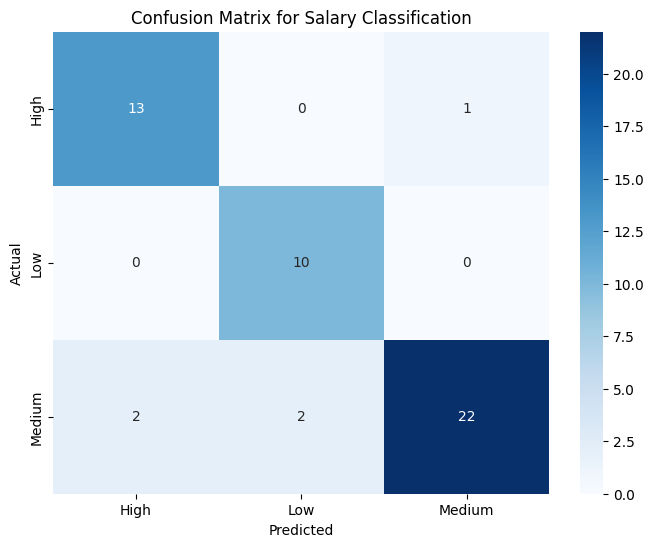

In [ ]:
#Logistic Regression
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv('employee_data.csv')
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Education'] = le.fit_transform(df['Education'])
df['Department'] = le.fit_transform(df['Department'])
df['Salary_Category_Encoded'] = le.fit_transform(df['Salary_Category'])
target_names = le.classes_
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category', 'Salary_Category_Encoded'], axis=1)
y = df['Salary_Category_Encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Logistic Regression Evaluation ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Salary Classification')
plt.show()

In [ ]:
#Randam Forest
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
df = pd.read_csv('employee_data.csv')
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Education'] = le.fit_transform(df['Education'])
df['Department'] = le.fit_transform(df['Department'])
df['Salary_Cat_Enc'] = le.fit_transform(df['Salary_Category'])
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category', 'Salary_Cat_Enc'], axis=1)
y_reg = df['Salary']
y_clf = df['Salary_Cat_Enc']
X_train, X_test, y_tr_reg, y_te_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_tr_clf, y_te_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_tr_reg)
rf_reg_pred = rf_reg.predict(X_test)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_tr_clf)
rf_clf_pred = rf_clf.predict(X_test_c)
lr = LinearRegression().fit(X_train, y_tr_reg)
lr_pred = lr.predict(X_test)
log_r = LogisticRegression(max_iter=1000).fit(X_train_c, y_tr_clf)
log_pred = log_r.predict(X_test_c)
print("--- REGRESSION COMPARISON (Predicting Salary Value) ---")
print(f"Linear Regression R² Score: {r2_score(y_te_reg, lr_pred):.4f}")
print(f"Random Forest R² Score:    {r2_score(y_te_reg, rf_reg_pred):.4f}")
print(f"Random Forest MAE:         ${mean_absolute_error(y_te_reg, rf_reg_pred):.2f}")
print("\n--- CLASSIFICATION COMPARISON (Predicting Salary Category) ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_te_clf, log_pred)*100:.2f}%")
print(f"Random Forest Accuracy:       {accuracy_score(y_te_clf, rf_clf_pred)*100:.2f}%")

--- REGRESSION COMPARISON (Predicting Salary Value) ---
Linear Regression R² Score: 0.9592
Random Forest R² Score:    0.9504
Random Forest MAE:         $5013.11

--- CLASSIFICATION COMPARISON (Predicting Salary Category) ---
Logistic Regression Accuracy: 90.00%
Random Forest Accuracy:       88.00%


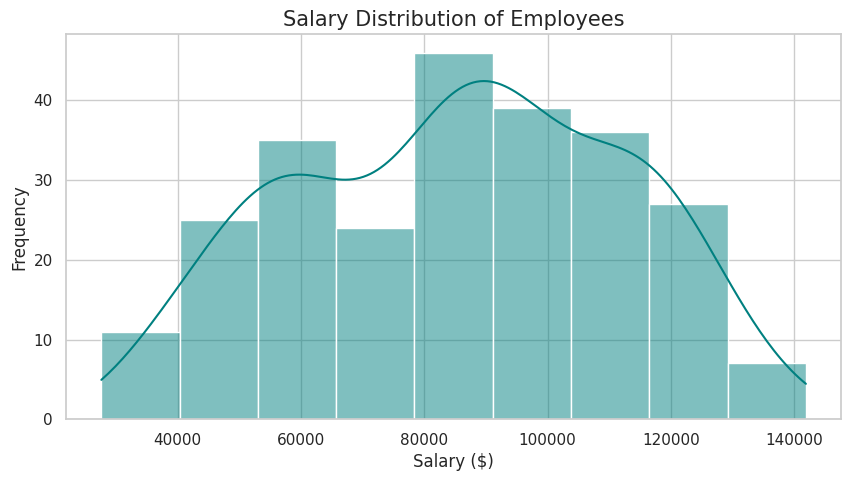

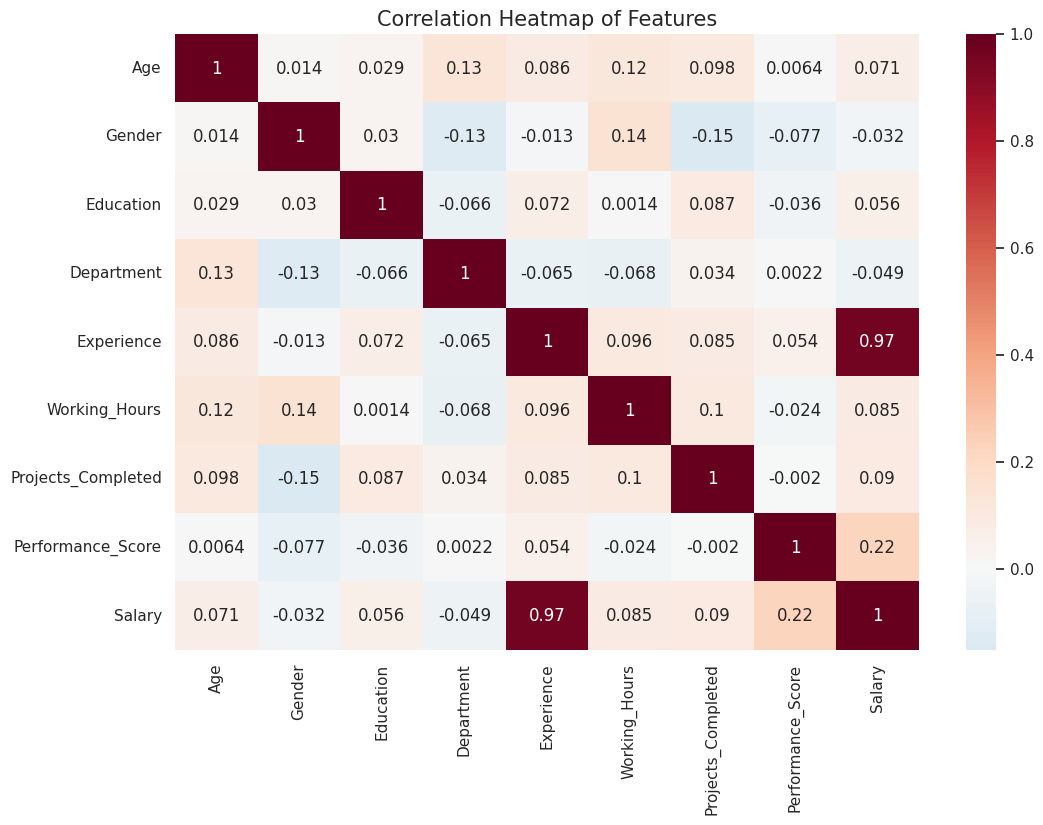

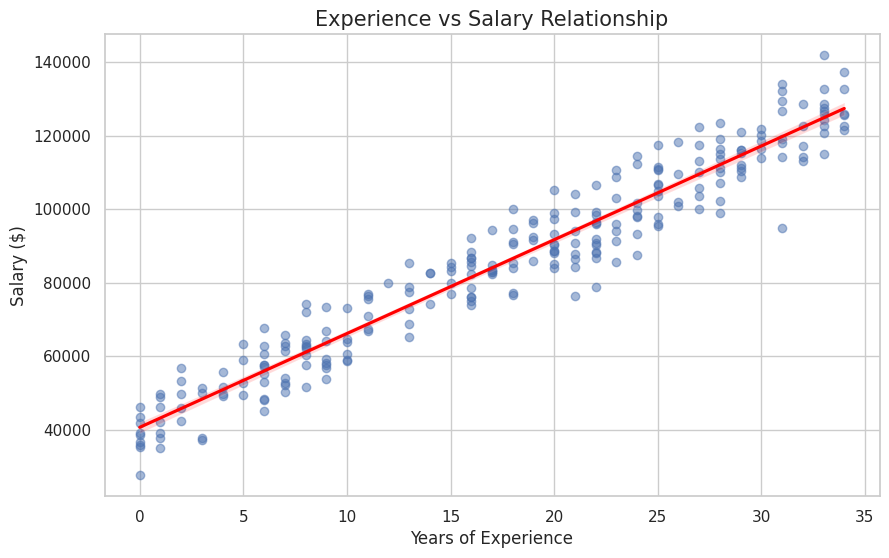

/tmp/ipykernel_5339/3478905273.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Salary', order=dept_order, palette='Set3')


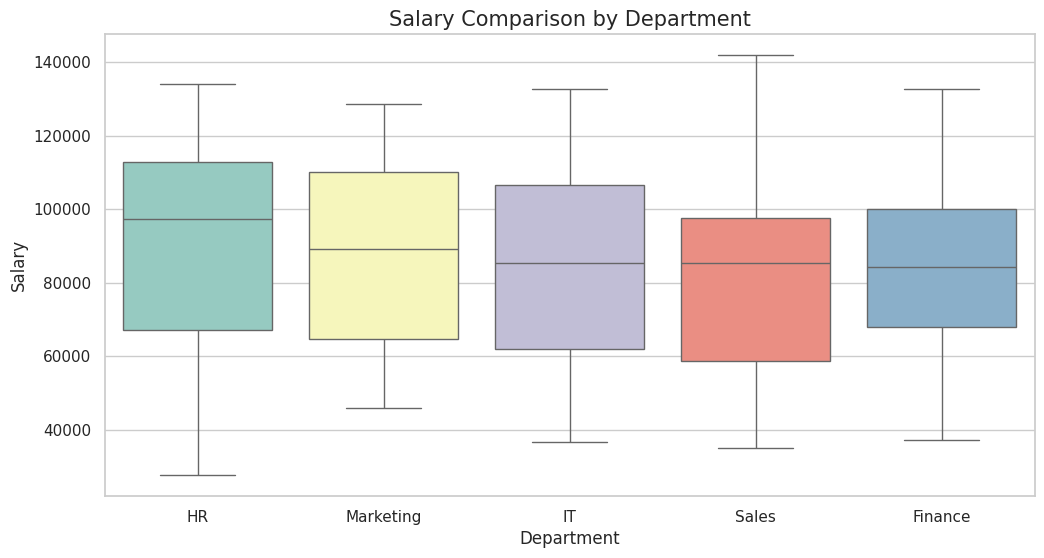

/tmp/ipykernel_5339/3478905273.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='magma')


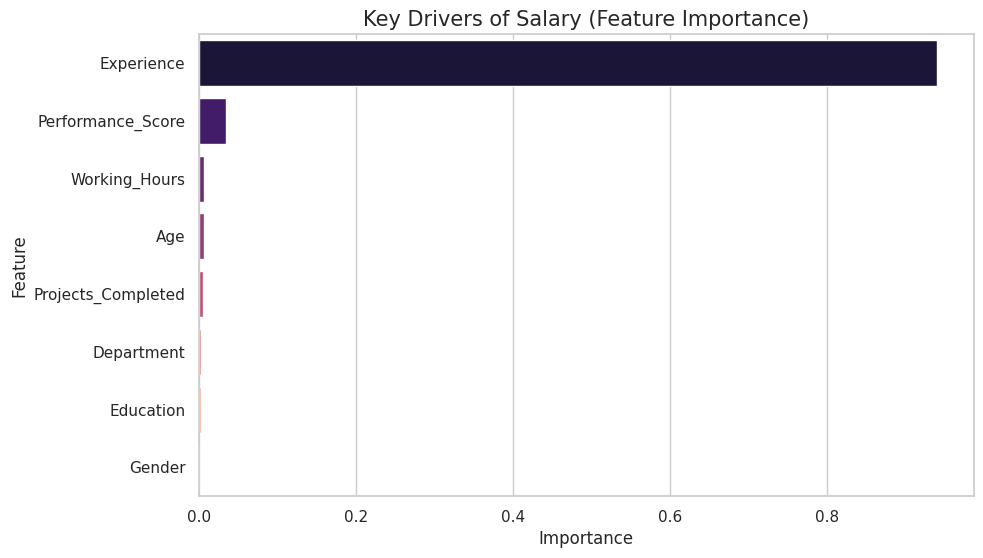

In [ ]:
#Visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('employee_data.csv')
df_encoded = df.copy()
le = LabelEncoder()
for col in ['Gender', 'Education', 'Department']:
    df_encoded[col] = le.fit_transform(df_encoded[col])
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(df['Salary'], kde=True, color='teal')
plt.title('Salary Distribution of Employees', fontsize=15)
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(12, 8))
corr_matrix = df_encoded.drop(['Employee_ID', 'Salary_Category'], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Features', fontsize=15)
plt.show()
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Experience', y='Salary', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Experience vs Salary Relationship', fontsize=15)
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.show()
plt.figure(figsize=(12, 6))
dept_order = df.groupby('Department')['Salary'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Department', y='Salary', order=dept_order, palette='Set3')
plt.title('Salary Comparison by Department', fontsize=15)
plt.show()
X = df_encoded.drop(['Employee_ID', 'Salary', 'Salary_Category'], axis=1)
y = df_encoded['Salary']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='magma')
plt.title('Key Drivers of Salary (Feature Importance)', fontsize=15)
plt.show()

--- REGRESSION MODEL COMPARISON ---
                                 MAE           MSE  R2 Score
Linear Regression        4578.823895  3.000105e+07  0.959154
Random Forest Regressor  5013.114000  3.646658e+07  0.950351

--- CLASSIFICATION MODEL COMPARISON ---
Logistic Regression Accuracy: 90.00%
Random Forest Classifier Accuracy: 88.00%


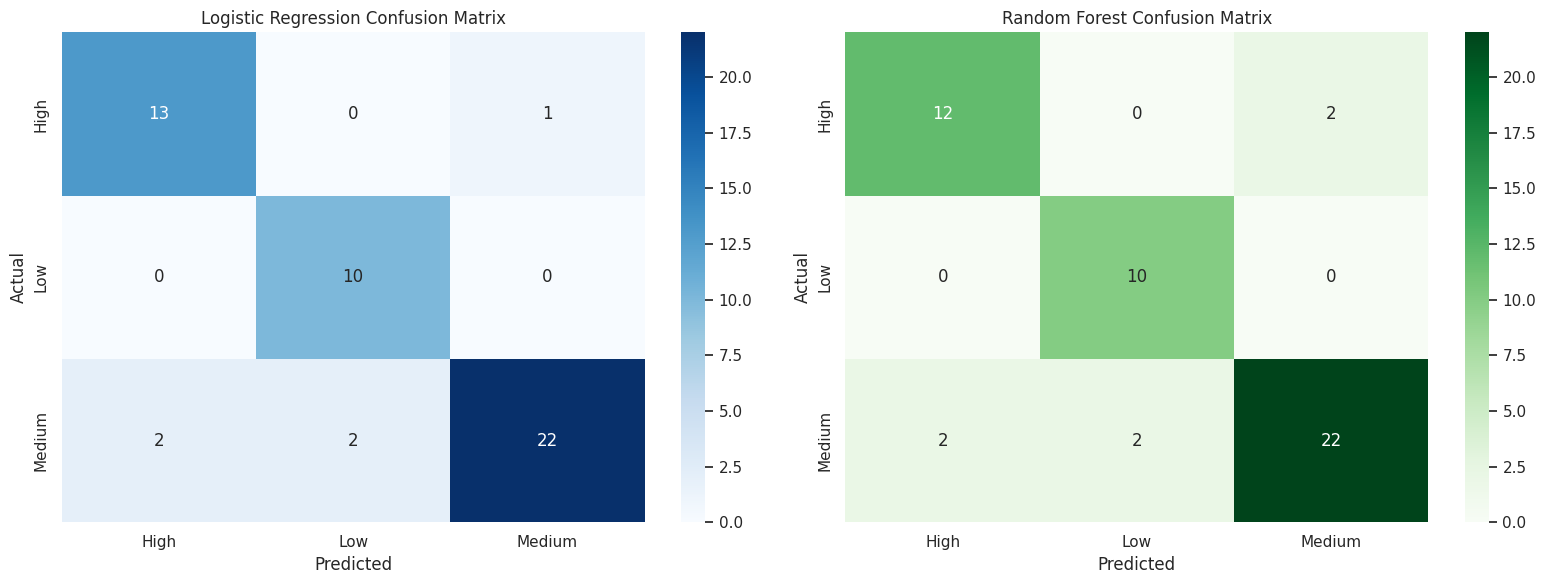

In [ ]:
#Model Evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,accuracy_score, confusion_matrix)
df = pd.read_csv('employee_data.csv')
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Education'] = le.fit_transform(df['Education'])
df['Department'] = le.fit_transform(df['Department'])
df['Salary_Cat_Enc'] = le.fit_transform(df['Salary_Category'])
cat_labels = le.classes_
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category', 'Salary_Cat_Enc'], axis=1)
y_reg = df['Salary']
y_clf = df['Salary_Cat_Enc']
X_train, X_test, y_tr_reg, y_te_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_tr_clf, y_te_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
lr = LinearRegression().fit(X_train_sc, y_tr_reg)
rf_r = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_tr_reg)
log_r = LogisticRegression(max_iter=1000).fit(X_train_sc, y_tr_clf)
rf_c = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_c, y_tr_clf)
def get_reg_metrics(model, X_vals, y_true, is_scaled=False):
    preds = model.predict(X_vals)
    return {
        'MAE': mean_absolute_error(y_true, preds),
        'MSE': mean_squared_error(y_true, preds),
        'R2 Score': r2_score(y_true, preds)
    }
reg_results = pd.DataFrame({
    'Linear Regression': get_reg_metrics(lr, X_test_sc, y_te_reg),
    'Random Forest Regressor': get_reg_metrics(rf_r, X_test, y_te_reg)
}).T
print("--- REGRESSION MODEL COMPARISON ---")
print(reg_results)
log_acc = accuracy_score(y_te_clf, log_r.predict(X_test_sc))
rf_acc = accuracy_score(y_te_clf, rf_c.predict(X_test_c))
print("\n--- CLASSIFICATION MODEL COMPARISON ---")
print(f"Logistic Regression Accuracy: {log_acc*100:.2f}%")
print(f"Random Forest Classifier Accuracy: {rf_acc*100:.2f}%")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_te_clf, log_r.predict(X_test_sc)), annot=True, fmt='d',
            cmap='Blues', xticklabels=cat_labels, yticklabels=cat_labels, ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')
sns.heatmap(confusion_matrix(y_te_clf, rf_c.predict(X_test_c)), annot=True, fmt='d',
            cmap='Greens', xticklabels=cat_labels, yticklabels=cat_labels, ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
ax[1].set_ylabel('Actual')
ax[1].set_xlabel('Predicted')
plt.tight_layout()
plt.show()